First 5 rows:
   N_SOIL  P_SOIL  K_SOIL  TEMPERATURE   HUMIDITY        ph    RAINFALL  \
0      90      42      43    20.879744  82.002744  6.502985  202.935536   
1      85      58      41    21.770462  80.319644  7.038096  226.655537   
2      60      55      44    23.004459  82.320763  7.840207  263.964248   
3      74      35      40    26.491096  80.158363  6.980401  242.864034   
4      78      42      42    20.130175  81.604873  7.628473  262.717340   

                 STATE  CROP_PRICE  CROP  
0  Andaman and Nicobar        7000  Rice  
1  Andaman and Nicobar        5000  Rice  
2  Andaman and Nicobar        7000  Rice  
3  Andaman and Nicobar        7000  Rice  
4  Andaman and Nicobar      120000  Rice  

Columns:
Index(['N_SOIL', 'P_SOIL', 'K_SOIL', 'TEMPERATURE', 'HUMIDITY', 'ph',
       'RAINFALL', 'STATE', 'CROP_PRICE', 'CROP'],
      dtype='object')
Target column: CROP

Linear Regression
R2: 0.348931140671878
MAE: 3.86591557580022
RMSE: 5.206289086206401

Decision Tree
R2

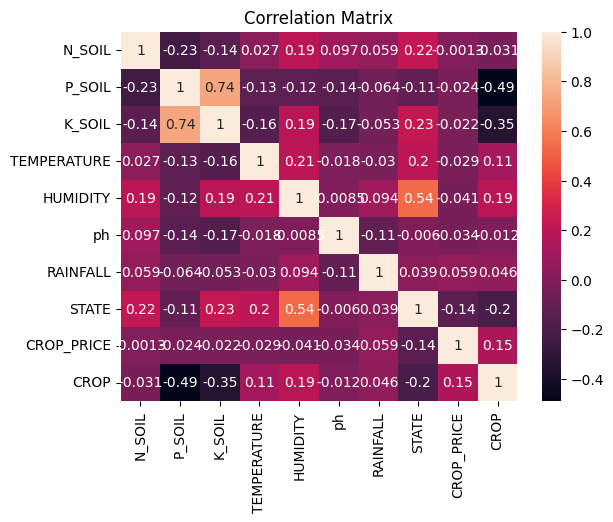

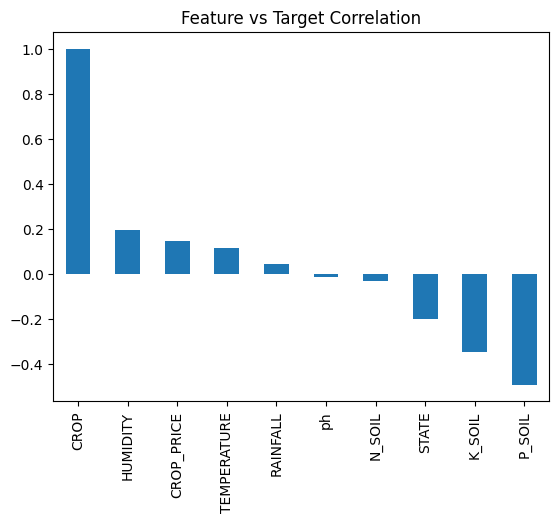

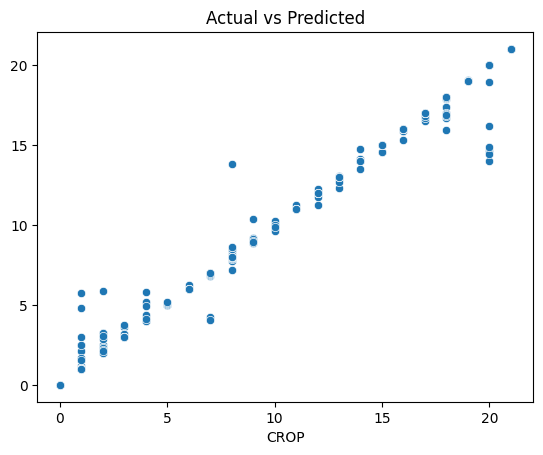

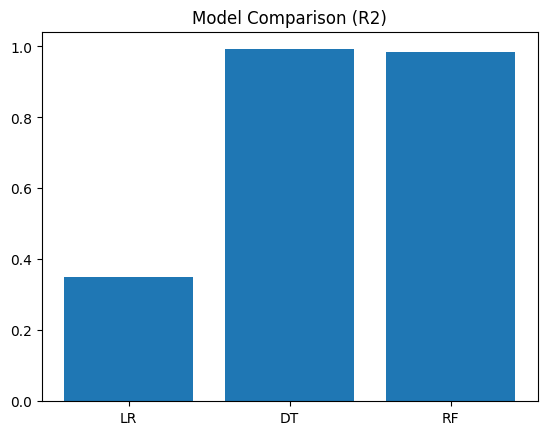

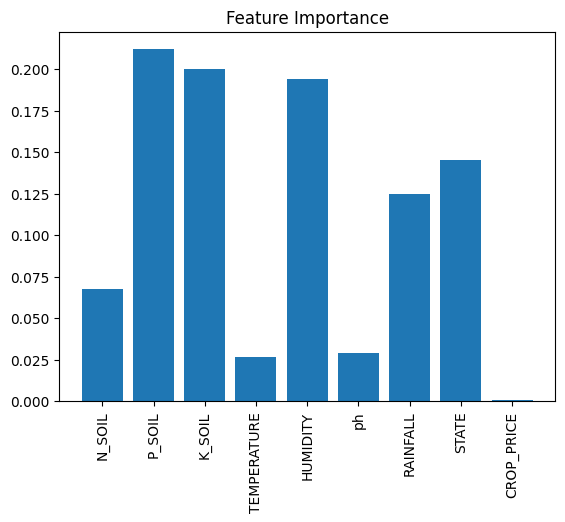

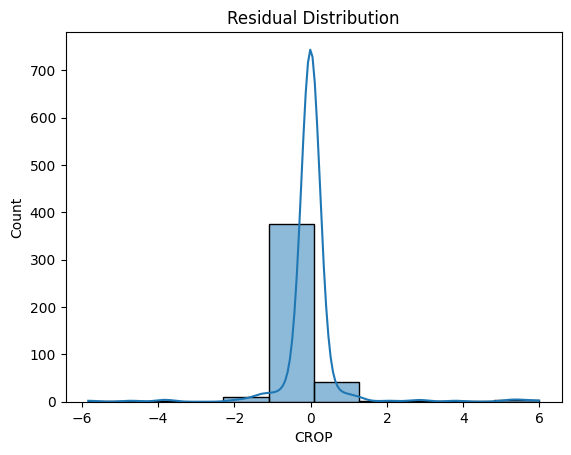

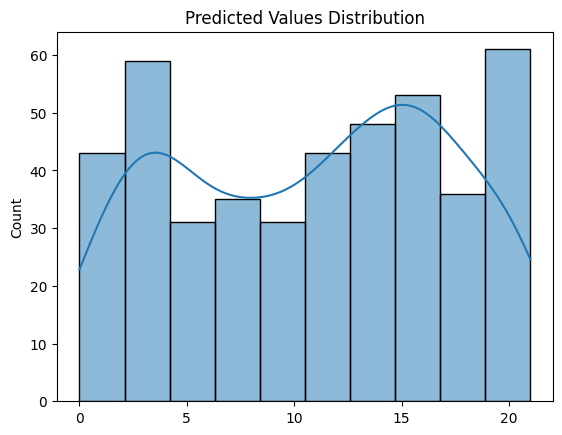

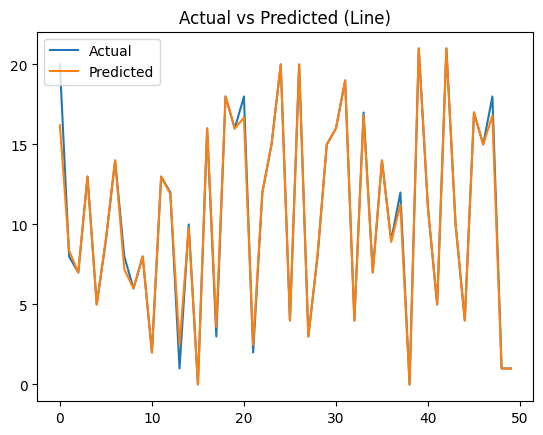


Sample Input:
    N_SOIL  P_SOIL  K_SOIL  TEMPERATURE  HUMIDITY        ph    RAINFALL  \
59      99      55      35    21.723831  80.23899  6.501698  277.962619   

    STATE  CROP_PRICE  
59      2        1000  
Predicted Output: 16.2


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


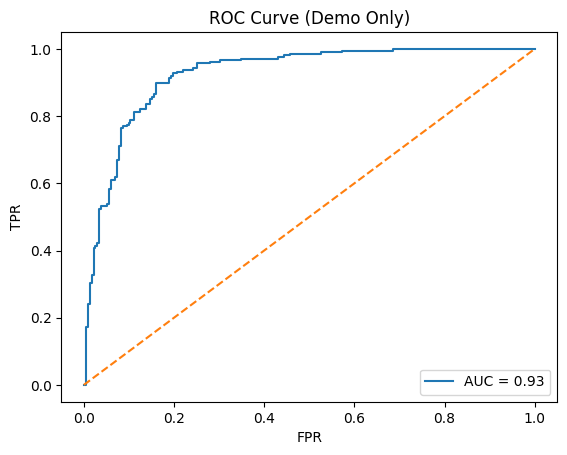

In [12]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# (Optional classification for ROC)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# =========================================
# 2. LOAD DATASET
# =========================================
df = pd.read_csv("/content/indiancrop_dataset.csv")

print("First 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

# =========================================
# 3. DATA CLEANING
# =========================================
df = df.dropna()

# =========================================
# 4. ENCODING
# =========================================
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# =========================================
# 5. TARGET AUTO DETECT
# =========================================
if 'Production' in df.columns:
    target = 'Production'
elif 'Yield' in df.columns:
    target = 'Yield'
else:
    target = df.columns[-1]

print("Target column:", target)

X = df.drop(target, axis=1)
y = df[target]

# =========================================
# 6. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# =========================================
# 7. MODELS (REGRESSION)
# =========================================
lr = LinearRegression()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor(n_estimators=100)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# =========================================
# 8. PREDICTIONS
# =========================================
pred_lr = lr.predict(X_test)
pred_dt = dt.predict(X_test)
pred_rf = rf.predict(X_test)

# =========================================
# 9. EVALUATION
# =========================================
def evaluate(name, y_test, pred):
    print(f"\n{name}")
    print("R2:", r2_score(y_test, pred))
    print("MAE:", mean_absolute_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

evaluate("Linear Regression", y_test, pred_lr)
evaluate("Decision Tree", y_test, pred_dt)
evaluate("Random Forest", y_test, pred_rf)

# =========================================
# 10. CORRELATION HEATMAP (ADVANCED)
# =========================================
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# =========================================
# 11. FEATURE vs TARGET
# =========================================
corr_target = df.corr()[target].sort_values(ascending=False)

plt.figure()
corr_target.plot(kind='bar')
plt.title("Feature vs Target Correlation")
plt.show()

# =========================================
# 12. ACTUAL vs PREDICTED
# =========================================
plt.figure()
sns.scatterplot(x=y_test, y=pred_rf)
plt.title("Actual vs Predicted")
plt.show()

# =========================================
# 13. MODEL COMPARISON
# =========================================
models = ["LR", "DT", "RF"]
scores = [
    r2_score(y_test, pred_lr),
    r2_score(y_test, pred_dt),
    r2_score(y_test, pred_rf)
]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison (R2)")
plt.show()

# =========================================
# 14. FEATURE IMPORTANCE
# =========================================
plt.figure()
plt.bar(X.columns, rf.feature_importances_)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

# =========================================
# 15. ERROR DISTRIBUTION
# =========================================
residuals = y_test - pred_rf

plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# =========================================
# 16. PREDICTION DISTRIBUTION
# =========================================
plt.figure()
sns.histplot(pred_rf, kde=True)
plt.title("Predicted Values Distribution")
plt.show()

# =========================================
# 17. LINE GRAPH COMPARISON
# =========================================
plt.figure()
plt.plot(y_test.values[:50], label="Actual")
plt.plot(pred_rf[:50], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (Line)")
plt.show()

# =========================================
# 18. SAMPLE PREDICTION
# =========================================
sample = X_test.iloc[0:1]
print("\nSample Input:")
print(sample)

print("Predicted Output:", rf.predict(sample)[0])

# =========================================
# 🔥 OPTIONAL: ROC CURVE (ONLY DEMO)
# =========================================
# Convert regression → classification
y_class = (y > y.median()).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2)

clf = LogisticRegression()
clf.fit(X_train_c, y_train_c)

probs = clf.predict_proba(X_test_c)[:,1]

fpr, tpr, _ = roc_curve(y_test_c, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve (Demo Only)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()